
# Lab1_3: PDE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Read
path = 'users/lucasperdomo/Fisica_Computacional_1/Sesiones/PDE/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'


#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

In [2]:
# Solucionando los ejercicios propuestos a laboratorio tenemos:

# Ejercicio 1: 

def Laplace(V_0, tol, x, y):

    Nmax = V_0.shape[0]
    V_old = V_0.copy()
    V_new = V_0.copy()

    M_Diferencia = float('inf')
    contador = 0 

    while M_Diferencia > tol:
        V_old = V_new.copy()

        for i in range(1, Nmax-1):
            for j in range(1, Nmax-1):
                V_new [i,j] = 0.25 * (V_old[i+1,j] + V_old[i-1,j] + V_old[i, j+1] + V_old[i, j-1])

        M_Diferencia = np.max(np.abs(V_new - V_old))
        contador += 1

    print(f'Hubo convergencia en la iteración {contador} con una diferencia máxima de {M_Diferencia:.6f}')

    X,Y = np.meshgrid(x,y)
    Z = V_new[X,Y]

    return X, Y, Z


In [8]:
# Aplicando la función al Ejercicio 1 tenemos:

#  ondiciones deseadas:
Nmax = 100
tol = 10e-4

#Matriz inicial:
V_0 = np.zeros((Nmax,Nmax), float)
for k in range(0, Nmax):
    V_0[k,0] = 100  # condiciones de Frontera

# Creamos array de Coordenadas y aplicamos la Función Laplace:
x = np.arange(0, Nmax-1, 1)
y = x

X, Y, Z = Laplace(V_0, tol, x, y)




Hubo convergencia en la iteración 5991 con una diferencia máxima de 0.001000


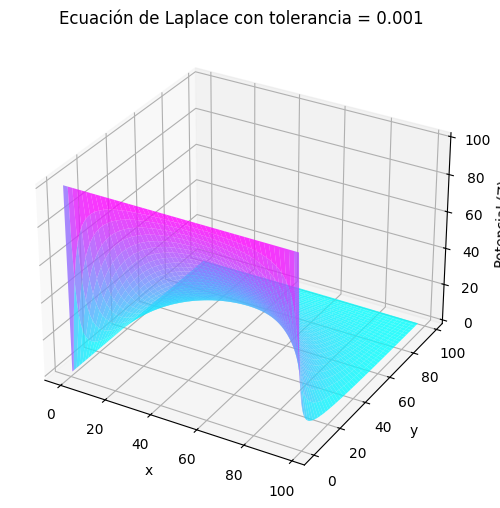

In [4]:
# Graficamos:

fig = plt.figure(figsize=(8,6))
ax_tol = fig.add_subplot(111, projection='3d') # Usar add_subplot en lugar de plt.axes
ax_tol.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax_tol.set_title(f'Ecuación de Laplace con tolerancia = {tol}')
ax_tol.set_xlabel('x')
ax_tol.set_ylabel('y')
ax_tol.set_zlabel('Potencial (Z)')
plt.show()


In [5]:
# HACIENDO COMPARACIÓN CON EL N-ESIMO MODO DE LA SERIE DE FOURIER TENEMOS:

def Fourier(x, y, n=1, L=1):
    v0 = 100
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)

#Aplicamos el criterio de tolerancia:
Nmax = 100 
L = Nmax

#Configuramos Arrays:
x_coor = np.arange(0, Nmax-1, 1)
y_coor = np.arange(0, Nmax-1, 1) 

# Creamos Malla 2D para graficar:
X_grid, Y_grid = np.meshgrid(x_coor, y_coor)

# Inicializamos z como array 2D de ceros:
z = np.zeros_like(X_grid, dtype= float)


tol_f = 0.0009
max_diff_fourier = float('inf')
n_terms = 1 
contador = 0
N_max_terminos = 40000

print(f'La serie de Fourier con Tolerancia {tol_f} es: ')

while max_diff_fourier > tol_f and contador < N_max_terminos:
    z_old = z.copy()

    term_n = Fourier(X_grid, Y_grid, n = n_terms, L=L)
    z += term_n

    diff = np.abs(z - z_old)
    if np.any(np.isnan(diff)):
        max_diff_fourier = float('inf')
    else:
        max_diff_fourier = np.max(diff)

    n_terms += 2
    contador += 1


print(f'La serie de Fourier converge en {contador} terminos de Fourier con una Tolerancia = {tol_f}')




La serie de Fourier con Tolerancia 0.0009 es: 


/var/folders/59/nnw34xf134xb_z8xlds9n4sh0000gn/T/ipykernel_4484/3142840856.py:8: RuntimeWarning: overflow encountered in sinh
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)
/var/folders/59/nnw34xf134xb_z8xlds9n4sh0000gn/T/ipykernel_4484/3142840856.py:8: RuntimeWarning: invalid value encountered in multiply
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)
/var/folders/59/nnw34xf134xb_z8xlds9n4sh0000gn/T/ipykernel_4484/3142840856.py:8: RuntimeWarning: invalid value encountered in divide
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)


La serie de Fourier converge en 40000 terminos de Fourier con una Tolerancia = 0.0009


In [6]:
# Vemos que la serie tiene errores en las convergencias del seno hiperbólico y no nos da una matriz nula; por lo tanto, vamos a usar mejores aproximaciones asintóticas para sinh(a)/sinh(b)=exp(a-b)
# Reorganizando de nuevo el código:

# HACIENDO COMPARACIÓN CON EL N-ESIMO MODO DE LA SERIE DE FOURIER TENEMOS:

def Fourier(x, y, n, L=1):
    v0 = 100
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    A = n*np.pi*(L - y_arr)/L
    B = n*np.pi

    ratio = np.exp(A - B)  # forma estable

    return (4*v0/(n*np.pi)) * np.sin(n*np.pi*x_arr/L) * ratio


#Aplicamos el criterio de tolerancia:
Nmax = 100 
L = Nmax

#Configuramos Arrays:
x_coor = np.arange(0, Nmax-1, 1)
y_coor = np.arange(0, Nmax-1, 1) 

# Creamos Malla 2D para graficar:
X_grid, Y_grid = np.meshgrid(x_coor, y_coor)

# Inicializamos z como array 2D de ceros:
z = np.zeros_like(X_grid, dtype= float)


tol_f = 0.0009
max_diff_fourier = float('inf')
n_terms = 1 
contador = 0
N_max_terminos = 40000

print(f'La serie de Fourier con Tolerancia {tol_f} es: ')

while max_diff_fourier > tol_f and contador < N_max_terminos:
    z_old = z.copy()

    term_n = Fourier(X_grid, Y_grid, n = n_terms, L=L)
    z += term_n

    diff = np.abs(z - z_old)
    if np.any(np.isnan(diff)):
        max_diff_fourier = float('inf')
    else:
        max_diff_fourier = np.max(diff)

    n_terms += 2
    contador += 1


print(f'La serie de Fourier converge en {contador} terminos con n max= {n_terms-2} con una Tolerancia = {tol_f}')



La serie de Fourier con Tolerancia 0.0009 es: 
La serie de Fourier converge en 40000 terminos con n max= 79999 con una Tolerancia = 0.0009


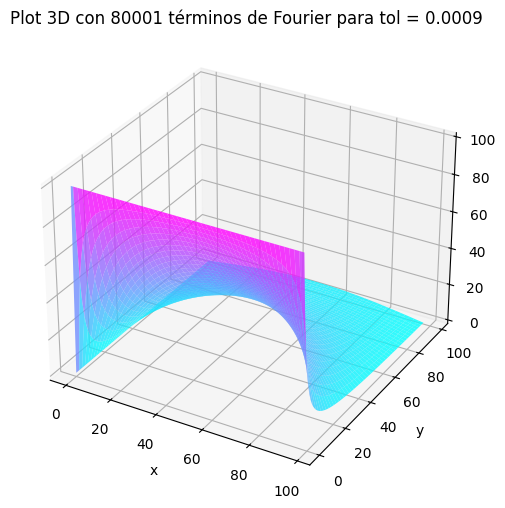

In [7]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
ax.plot_surface(X_grid, Y_grid, z, cmap= 'cool', alpha=0.8)
ax.set_title(f'Plot 3D con {n_terms} términos de Fourier para tol = {tol_f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

#### **Solution Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

In [ ]:
# utilizando el método de Jacobbi ya que tenemos una solución anlítica con modos n=2, podemos reescribir al función utilizada en el ejercicio 1 de la siguuiente manera, 
# añadiendo las condiciones de frontera necesarias:

def Laplace(V_0, tol, x, y):
    Nmax = V_0.shape[0]
    
    V_new = V_0.copy()
    V_old = V_0.copy()

    M_Diferencia = float('inf')
    contador = 0

    while M_Diferencia > tol:
        V_old = V_new.copy()

        # Jacobi vectorizado
        V_new[1:-1,1:-1] = 0.25*(
            V_old[2:,1:-1] + 
            V_old[:-2,1:-1] + 
            V_old[1:-1,2:] + 
            V_old[1:-1,:-2]
        )

        # Condiciones de frontera
        V_new[0,:] = 0
        V_new[-1,:] = 0
        V_new[:,-1] = 0
        V_new[:,0] = V_0[:,0]

        # Error
        M_Diferencia = np.max(np.abs(V_new - V_old))
        contador += 1

    print(f'Convergió en {contador} iteraciones con error {M_Diferencia:.6e}')

    return V_new

Convergió en 2326 iteraciones con error 9.992287e-04


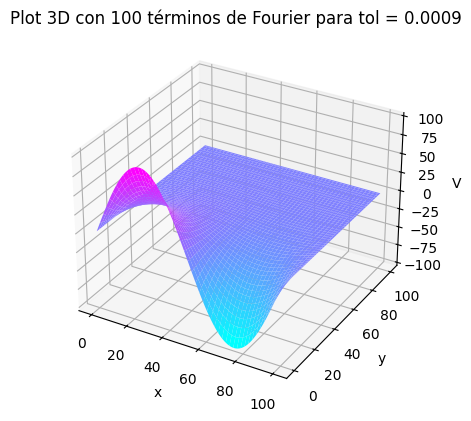

In [13]:
# Utilizamos la función dadas nuestras condiciones iniciales: 

L = 100
N = 100
u0 = 100

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)

V_0 = np.zeros((N,N))
V_0[:,0] = u0 * np.sin(2*np.pi*x/L)

V = Laplace(V_0, tol, x, y)

# Grafiando:
X, Y = np.meshgrid(x, y)
plt.figure()
ax = plt.axes(projection='3d')
ax.set_title(f'Plot 3D con {N} términos de Fourier para tol = {tol_f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('V')
ax.plot_surface(X, Y, V.T, cmap='cool')  # Se utiliza el .T para transportar en la grficación de la matriz.
